3.4.2.1 VARIABLE DESCRIPTIONS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/interim/cleaned_transactions.csv", parse_dates=["InvoiceDate"])

# Variable summary
var_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isnull().sum(),
    "unique": df.nunique()
})
display(var_summary)
df.describe(include="all")



,dtype,missing,unique
Invoice,object,0,23585
StockCode,object,0,4031
Description,object,0,4459
Quantity,int64,0,500
InvoiceDate,datetime64[ns],0,21784
Price,float64,0,663
Customer ID,int64,0,4381
Country,object,0,37
TransactionValue,float64,0,3510
IsReturn,bool,0,2


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TransactionValue,IsReturn
count,410732,410732,410732,410732.000000,410732,410732.000000,410732.000000,410732,410732.000000,410732
unique,23585,4031,4459,NaN,NaN,NaN,NaN,37,NaN,2
top,500356,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom,NaN,False
freq,251,3199,3199,NaN,NaN,NaN,NaN,372683,NaN,400916
mean,NaN,NaN,NaN,12.922592,2010-06-30 20:01:09.827138304,3.908653,15353.708564,NaN,20.243993,NaN
min,NaN,NaN,NaN,-9360.000000,2009-12-01 07:45:00,0.001000,12346.000000,NaN,-25111.090000,NaN
25%,NaN,NaN,NaN,2.000000,2010-03-26 09:46:00,1.250000,13979.000000,NaN,4.500000,NaN
50%,NaN,NaN,NaN,5.000000,2010-07-08 15:29:00,1.950000,15311.000000,NaN,11.800000,NaN
75%,NaN,NaN,NaN,12.000000,2010-10-14 12:32:00,3.750000,16797.000000,NaN,19.500000,NaN
max,NaN,NaN,NaN,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,NaN,15818.400000,NaN


3.4.2.2 DISTRIBUTION ANALYSIS (UNIVARIATE)

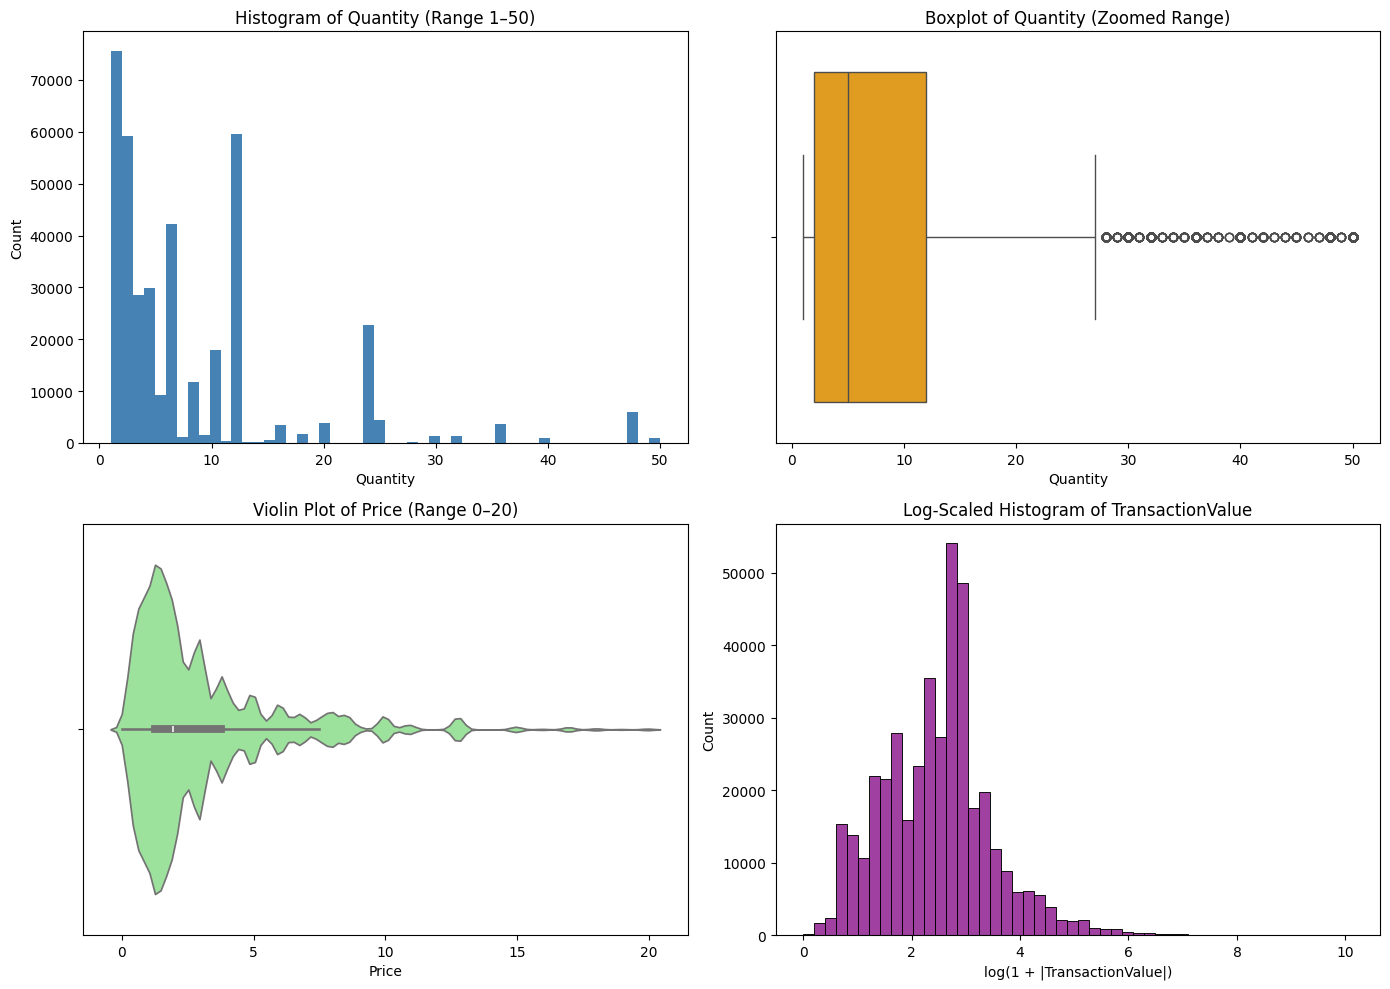

In [ ]:

# Subset for better visibility
qty_subset = df[(df['Quantity'] > 0) & (df['Quantity'] <= 50)]
price_subset = df[(df['Price'] > 0) & (df['Price'] <= 20)]
tv_subset = df[(df['TransactionValue'] > 0) & (df['TransactionValue'] <= 100)]

# Create figure
plt.figure(figsize=(14, 10))

# ---------------------------------------------
# 1. Histogram (Quantity)
# ---------------------------------------------
plt.subplot(2, 2, 1)
plt.hist(qty_subset['Quantity'], bins=50, color='steelblue')
plt.title("Histogram of Quantity (Range 1–50)")
plt.xlabel("Quantity")
plt.ylabel("Count")

# ---------------------------------------------
# 2. Boxplot (Quantity)
# ---------------------------------------------
plt.subplot(2, 2, 2)
sns.boxplot(x=qty_subset['Quantity'], color='orange')
plt.title("Boxplot of Quantity (Zoomed Range)")
plt.xlabel("Quantity")

# ---------------------------------------------
# 3. Violin Plot (Price)
# ---------------------------------------------
plt.subplot(2, 2, 3)
sns.violinplot(x=price_subset['Price'], color='lightgreen')
plt.title("Violin Plot of Price (Range 0–20)")
plt.xlabel("Price")

# ---------------------------------------------
# 4. Log Histogram for Transaction Value
# ---------------------------------------------
plt.subplot(2, 2, 4)
log_tv = np.log1p(df['TransactionValue'].abs())
sns.histplot(log_tv, bins=50, color='purple')
plt.title("Log-Scaled Histogram of TransactionValue")
plt.xlabel("log(1 + |TransactionValue|)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


3.4.2.3 BIVARIATE RELATIONSHIPS

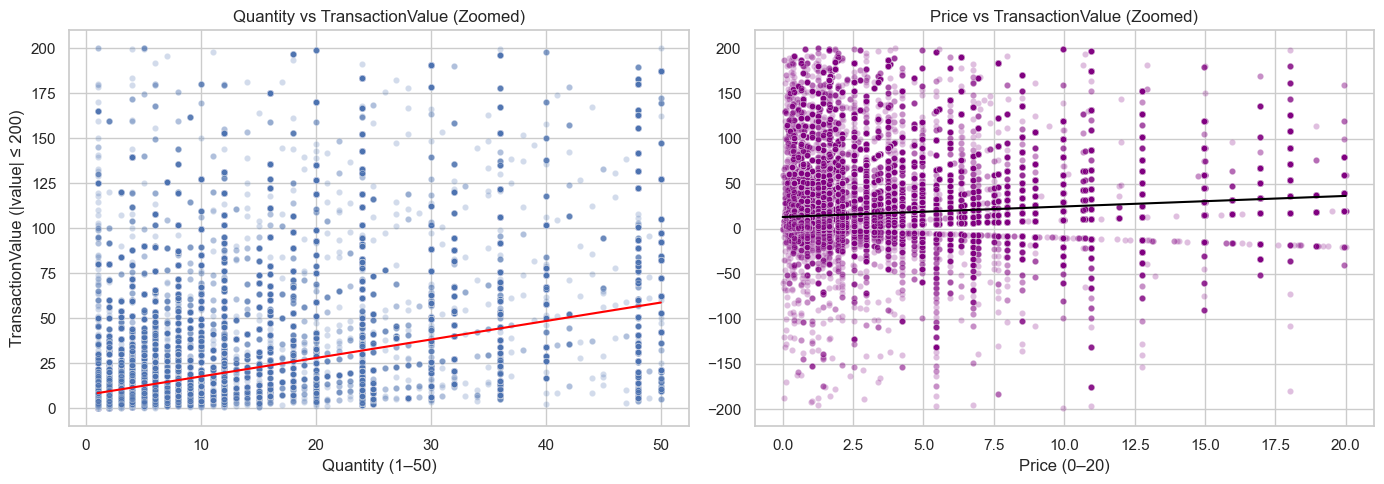

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Create side-by-side axes
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# --------- Left plot: Quantity vs TransactionValue ----------
sns.scatterplot(
    data=subset,
    x="Quantity",
    y="TransactionValue",
    alpha=0.25,
    s=20,
    ax=axes[0]
)
sns.regplot(
    data=subset,
    x="Quantity",
    y="TransactionValue",
    scatter=False,
    color="red",
    line_kws={"linewidth":1.5},
    ax=axes[0]
)
axes[0].set_title("Quantity vs TransactionValue (Zoomed)")
axes[0].set_xlabel("Quantity (1–50)")
axes[0].set_ylabel("TransactionValue (|value| ≤ 200)")

# --------- Right plot: Price vs TransactionValue ----------
sns.scatterplot(
    data=subset_price,
    x="Price",
    y="TransactionValue",
    alpha=0.25,
    s=20,
    color="purple",
    ax=axes[1]
)
sns.regplot(
    data=subset_price,
    x="Price",
    y="TransactionValue",
    scatter=False,
    color="black",
    line_kws={"linewidth":1.5},
    ax=axes[1]
)
axes[1].set_title("Price vs TransactionValue (Zoomed)")
axes[1].set_xlabel("Price (0–20)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


3.4.2.4 TEMPORAL SPENDING PATTERNS

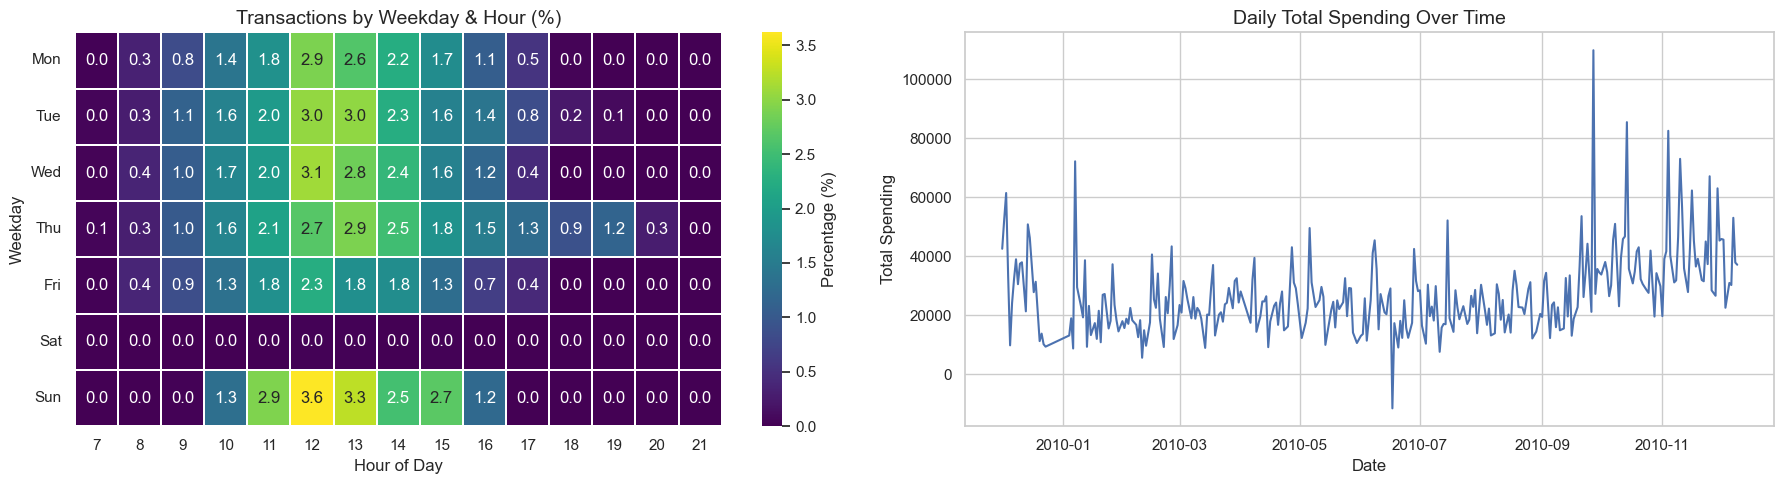

In [ ]:

# Extract weekday and hour
df["weekday"] = df["InvoiceDate"].dt.weekday
df["hour"] = df["InvoiceDate"].dt.hour

# Pivot: count of transactions
pivot = df.pivot_table(
    values="TransactionValue",
    index="weekday",
    columns="hour",
    aggfunc="count",
    fill_value=0
)

# Convert to percentages
pivot_pct = pivot / pivot.sum().sum() * 100

weekday_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

# Prepare shared figure
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# -------- LEFT: Percentage Heatmap --------
sns.heatmap(
    pivot_pct,
    cmap="viridis",
    linewidths=0.3,
    linecolor="white",
    annot=True,      # show percentages
    fmt=".1f",       # 1 decimal place
    cbar_kws={"label": "Percentage (%)"},
    ax=axes[0]
)

axes[0].set_title("Transactions by Weekday & Hour (%)", fontsize=14)
axes[0].set_xlabel("Hour of Day", fontsize=12)
axes[0].set_ylabel("Weekday", fontsize=12)
axes[0].set_yticks([i + 0.5 for i in range(7)])
axes[0].set_yticklabels(weekday_labels, rotation=0)

# -------- RIGHT: Daily Spending Line Plot --------
df["Day"] = df["InvoiceDate"].dt.date
daily = df.groupby("Day")["TransactionValue"].sum()

axes[1].plot(daily.index, daily.values)
axes[1].set_title("Daily Total Spending Over Time", fontsize=14)
axes[1].set_xlabel("Date", fontsize=12)
axes[1].set_ylabel("Total Spending", fontsize=12)

plt.tight_layout()
plt.show()


3.4.2.5 CUSTOMER BEHAVIOUR PROFILING

d:\THIRD_YEAR\FYP\cmab_data_pipeline\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


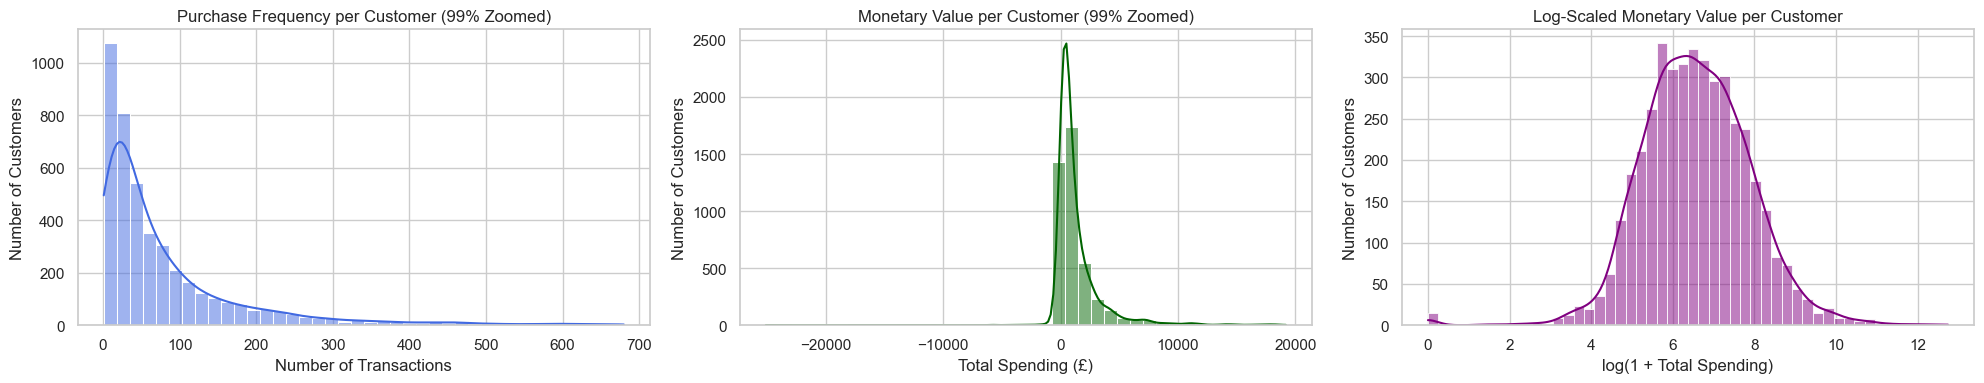

In [ ]:

# --- Customer purchase frequency ---
cust_freq = df.groupby("Customer ID")["Invoice"].count()
freq_zoom = cust_freq[cust_freq <= np.percentile(cust_freq, 99)]

# --- Customer monetary value ---
cust_monetary = df.groupby("Customer ID")["TransactionValue"].sum()
monetary_zoom = cust_monetary[cust_monetary <= np.percentile(cust_monetary, 99)]

# --- Combined figure with 3 subplots ---
fig, axes = plt.subplots(1, 3, figsize=(20, 4))

# -------- 1. Purchase Frequency Distribution --------
sns.histplot(freq_zoom, bins=40, kde=True, color="royalblue", ax=axes[0])
axes[0].set_title("Purchase Frequency per Customer (99% Zoomed)")
axes[0].set_xlabel("Number of Transactions")
axes[0].set_ylabel("Number of Customers")

# -------- 2. Monetary Value Distribution --------
sns.histplot(monetary_zoom, bins=40, kde=True, color="darkgreen", ax=axes[1])
axes[1].set_title("Monetary Value per Customer (99% Zoomed)")
axes[1].set_xlabel("Total Spending (£)")
axes[1].set_ylabel("Number of Customers")

# -------- 3. Log-Scaled Monetary Value --------
sns.histplot(np.log1p(cust_monetary), bins=50, kde=True, color="purple", ax=axes[2])
axes[2].set_title("Log-Scaled Monetary Value per Customer")
axes[2].set_xlabel("log(1 + Total Spending)")
axes[2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()


3.4.2.6 COUNTRY-LEVEL BEHAVIOUR

C:\Users\User\AppData\Local\Temp\ipykernel_32384\1530671698.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


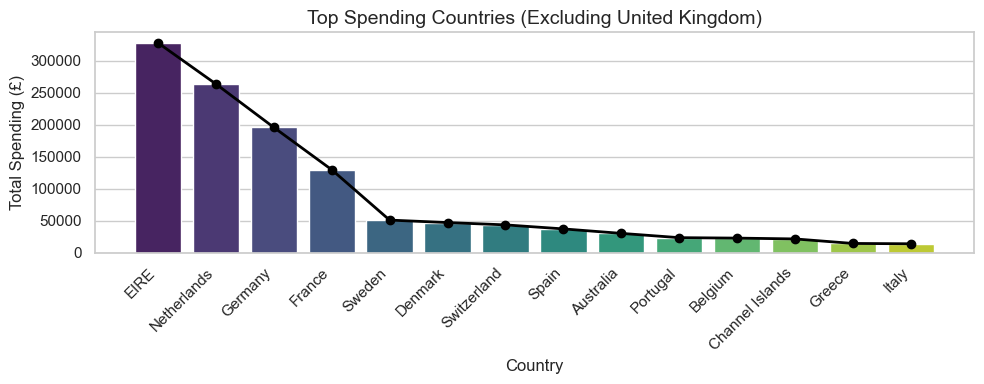

In [41]:
non_uk = country_spend.drop("United Kingdom")

plt.figure(figsize=(10,4))

# --- Bars ---
sns.barplot(
    x=non_uk.index,
    y=non_uk.values,
    palette="viridis"
)

# --- Line across bar tops ---
plt.plot(
    range(len(non_uk)),
    non_uk.values,
    marker="o",
    linestyle="-",
    color="black",
    linewidth=2
)

plt.xticks(rotation=45, ha="right")
plt.title("Top Spending Countries (Excluding United Kingdom)", fontsize=14)
plt.ylabel("Total Spending (£)")
plt.tight_layout()
plt.show()


3.4.2.7 COHORT ANALYSIS

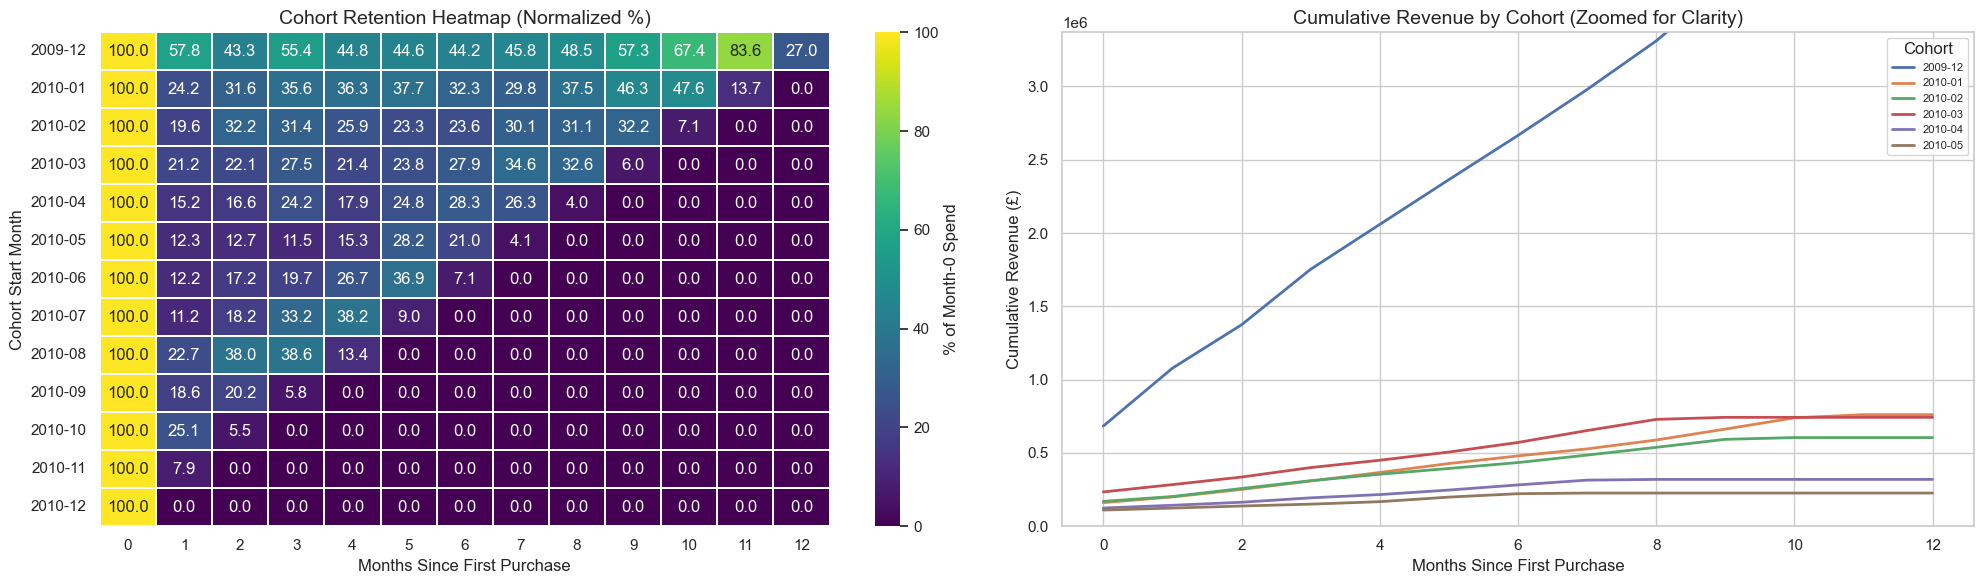

In [ ]:

# Ensure we only use valid purchase transactions
df_clean = df[df["IsReturn"] == False].copy()

# =========================
# COHORT FEATURE ENGINEERING
# =========================

df_clean["invoice_month"] = df_clean["InvoiceDate"].dt.to_period("M")
df_clean["first_purchase_month"] = df_clean.groupby("Customer ID")["invoice_month"].transform("min")
df_clean["cohort_index"] = (df_clean["invoice_month"] - df_clean["first_purchase_month"]).apply(lambda x: x.n)

# Cohort revenue matrix
cohort_matrix = df_clean.pivot_table(
    index="first_purchase_month",
    columns="cohort_index",
    values="TransactionValue",
    aggfunc="sum"
).fillna(0)

# Cohort sizes
cohort_sizes = df_clean.groupby("first_purchase_month")["Customer ID"].nunique()

# Normalize revenue per customer
cohort_norm = cohort_matrix.div(cohort_sizes, axis=0)

# Retention ratio relative to Month 0
cohort_ratio = cohort_norm.div(cohort_norm[0], axis=0) * 100
cohort_ratio.index = cohort_ratio.index.astype(str)

# Cumulative revenue
cohort_cumulative = cohort_matrix.cumsum(axis=1)
cohort_cumulative.index = cohort_cumulative.index.astype(str)

# =========================
# COMBINED VISUALIZATION
# =========================

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# LEFT: Retention Heatmap
sns.heatmap(
    cohort_ratio,
    cmap="viridis",
    annot=True,
    fmt=".1f",
    linewidths=0.3,
    cbar_kws={"label": "% of Month-0 Spend"},
    ax=axes[0]
)

axes[0].set_title("Cohort Retention Heatmap (Normalized %)", fontsize=14)
axes[0].set_xlabel("Months Since First Purchase")
axes[0].set_ylabel("Cohort Start Month")

# RIGHT: Cumulative Revenue (limited to 6 cohorts for readability)
plot_cohorts = cohort_cumulative.head(6)

for cohort in plot_cohorts.index:
    axes[1].plot(
        plot_cohorts.columns,
        plot_cohorts.loc[cohort],
        linewidth=2,
        label=cohort
    )

upper_limit = np.percentile(plot_cohorts.values, 95)
axes[1].set_ylim(0, upper_limit)

axes[1].set_title("Cumulative Revenue by Cohort (Zoomed for Clarity)", fontsize=14)
axes[1].set_xlabel("Months Since First Purchase")
axes[1].set_ylabel("Cumulative Revenue (£)")
axes[1].legend(title="Cohort", fontsize=8)

plt.tight_layout()
plt.show()


3.4.2.8 CORRELATION HEATMAP

C:\Users\User\AppData\Local\Temp\ipykernel_32384\2666810633.py:54: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


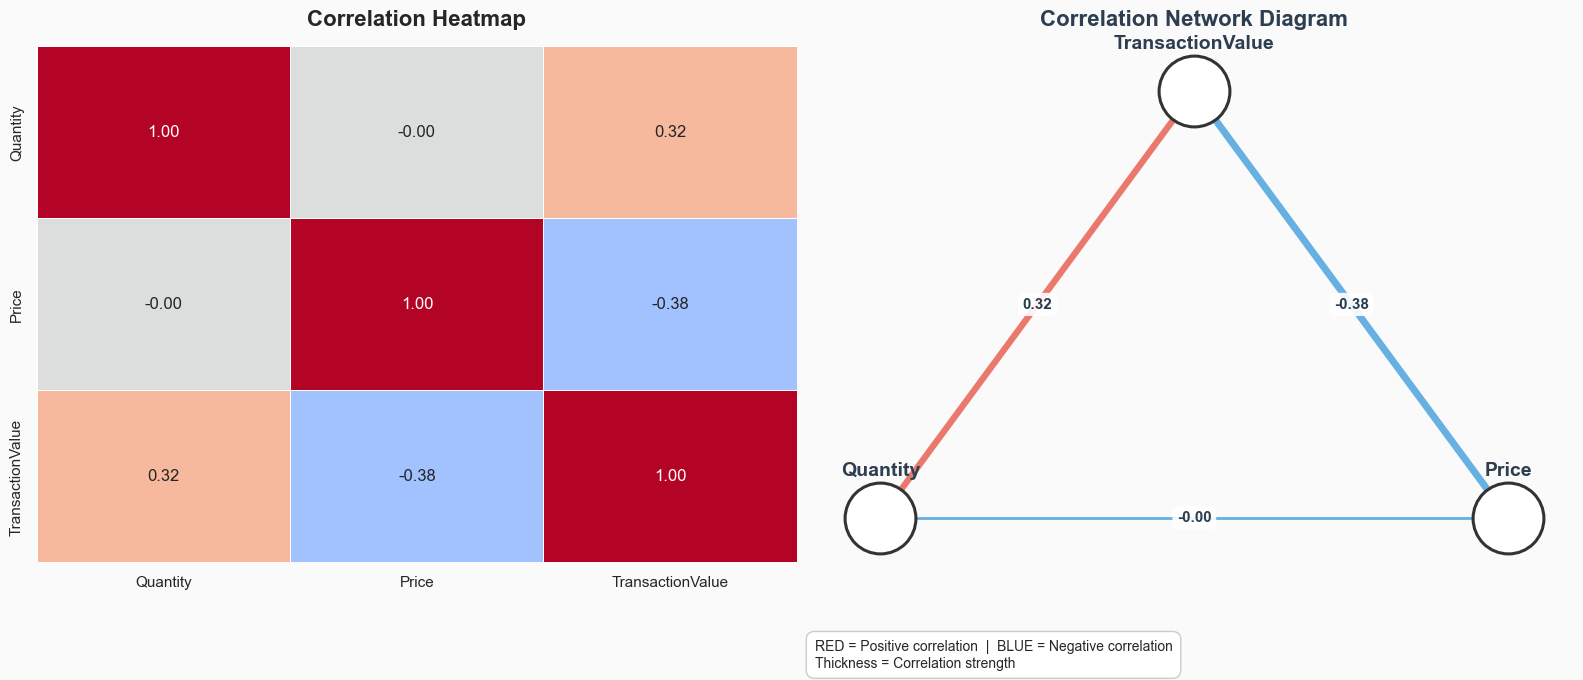

In [71]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

corr = df[["Quantity", "Price", "TransactionValue"]].corr()

# ---------------------------
# BUILD NETWORK GRAPH
# ---------------------------
G = nx.Graph()
for i, col_i in enumerate(corr.columns):
    for col_j in corr.columns[i+1:]:
        G.add_edge(col_i, col_j, weight=corr.loc[col_i, col_j])

# Perfect triangle layout
pos = {
    corr.columns[0]: (-1, -0.5),
    corr.columns[1]: (1, -0.5),
    corr.columns[2]: (0, 1),
}

weights = np.array([d["weight"] for _, _, d in G.edges(data=True)])
edge_colors = ["#e74c3c" if w > 0 else "#3498db" for w in weights]
edge_widths = 2 + (abs(weights) * 8)

# ---------------------------
# COMBINED FIGURE
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("#fafafa")

# ==========================================================
# LEFT: Heatmap
# ==========================================================
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar=False,
    ax=axes[0]
)
axes[0].set_title("Correlation Heatmap", fontsize=16, fontweight="bold", pad=15)

# ==========================================================
# RIGHT: Correlation Network Diagram (Triangle)
# ==========================================================
ax = axes[1]

# Curved edges
nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.75,
    connectionstyle="arc3,rad=0.25",
    ax=ax
)

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=2600,
    node_color="white",
    edgecolors="#333",
    linewidths=2.2,
    ax=ax
)

# Node labels
for node, (x, y) in pos.items():
    ax.text(
        x, y + 0.15,
        node,
        fontsize=14,
        fontweight="bold",
        color="#2c3e50",
        ha="center"
    )

# Edge correlation labels
for (u, v), weight in zip(G.edges(), weights):
    x = (pos[u][0] + pos[v][0]) / 2
    y = (pos[u][1] + pos[v][1]) / 2
    ax.text(
        x, y,
        f"{weight:.2f}",
        fontsize=11,
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.9),
        fontweight="bold",
        color="#2c3e50"
    )

# Title
ax.set_title("Correlation Network Diagram", fontsize=16, fontweight="bold", pad=15, color="#2c3e50")

# Legend
ax.text(
    0.0, -0.15,
    "RED = Positive correlation  |  BLUE = Negative correlation\nThickness = Correlation strength",
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.6", facecolor="white", edgecolor="#ccc"),
    ha="left",
    va="top"
)

ax.axis("off")

plt.tight_layout()
plt.show()


3.4.2.9 INSIGHTS → FEATURE ENGINEERING MAPPING

In [72]:
print("SUMMARY CHECKLIST FOR FEATURE ENGINEERING")
print("- Heavy skew in spending → log or normalized monetary features")
print("- Time-of-day/weekday peaks → time-context features")
print("- Customer heterogeneity → per-user normalization")
print("- Return behaviour → return_rate feature")
print("- Quantity/Price clusters → behavioural segment features")


SUMMARY CHECKLIST FOR FEATURE ENGINEERING
- Heavy skew in spending → log or normalized monetary features
- Time-of-day/weekday peaks → time-context features
- Customer heterogeneity → per-user normalization
- Return behaviour → return_rate feature
- Quantity/Price clusters → behavioural segment features


C:\Users\User\AppData\Local\Temp\ipykernel_32384\1919144583.py:35: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_32384\1919144583.py:35: UserWarning: Glyph 10004 (\N{HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
d:\THIRD_YEAR\FYP\cmab_data_pipeline\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
d:\THIRD_YEAR\FYP\cmab_data_pipeline\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10004 (\N{HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


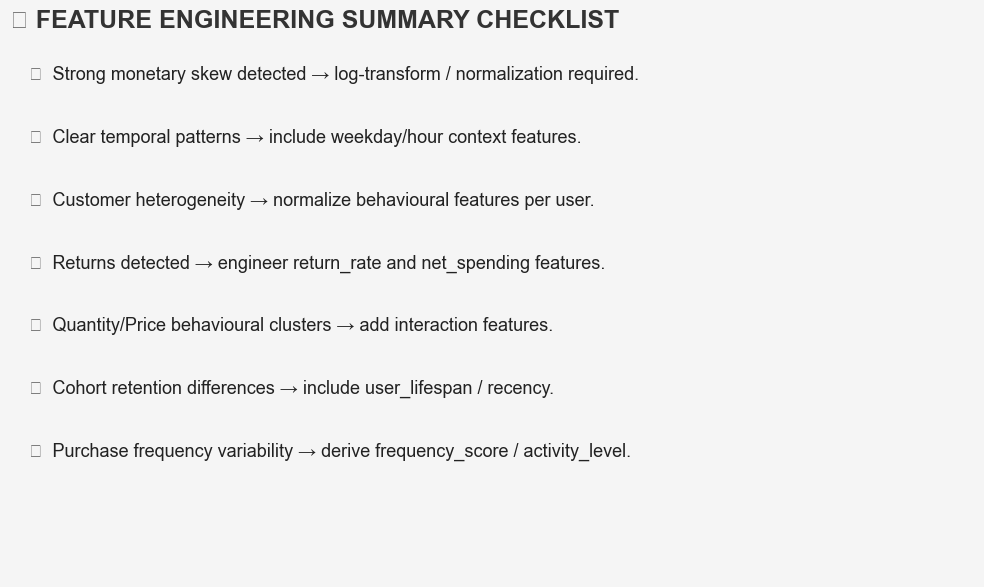

In [74]:
import matplotlib.pyplot as plt

items = [
    "Strong monetary skew detected → log-transform / normalization required.",
    "Clear temporal patterns → include weekday/hour context features.",
    "Customer heterogeneity → normalize behavioural features per user.",
    "Returns detected → engineer return_rate and net_spending features.",
    "Quantity/Price behavioural clusters → add interaction features.",
    "Cohort retention differences → include user_lifespan / recency.",
    "Purchase frequency variability → derive frequency_score / activity_level."
]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#f5f5f5")
ax.axis("off")

ax.text(
    0.0, 1.05,
    "📌 FEATURE ENGINEERING SUMMARY CHECKLIST",
    fontsize=18,
    fontweight="bold",
    color="#333"
)

y = 0.95
for i, item in enumerate(items, start=1):
    ax.text(
        0.02, y,
        f"✔  {item}",
        fontsize=13,
        color="#222"
    )
    y -= 0.12

plt.tight_layout()
plt.show()
